In [58]:
#if your cell keeps throwing import errors, run the following pip installs to get the correct libraries in place.
# uncomment if needed.
# !pip install cartopy
# !pip install cdsapi
# !pip install xarray
# !pip install matplotlib

import xarray as xr
import matplotlib.pyplot as plt
import os
import cartopy
import numpy as np
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.crs as ccrs
import matplotlib as mpl
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import datetime
import cdsapi
import zipfile
import pandas as pd
import requests
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import ipywidgets as widgets
from IPython.display import display


In [59]:
product_parameters = {
    'XCO2_OBS4MIPS': {
        'satellite'           : 'MERGED',   # make sure to use the correct satellite name as per the manifest file
        'instrument'          : 'MERGED', # make sure to use the correct instrument name as per the manifest file
        'algorithm'           : 'OBS4MIPS',    # trying to make this generic enough. most datasets only have a generic 'ALG'
        'version'             : 'v5.1',  # make sure to use the correct version as per the manifest file
        'GHG_name'            : 'XCO2',  # XCO2 or XCH4
        'delivery_start'      : pd.Timestamp('01/01/2003'), # start date of *this* delivery
        'delivery_end'        : pd.Timestamp('31/12/2024'),
        'collection_start'    : pd.Timestamp('01/01/2003'), # start date of the *whole* dataset
        'collection_end'      : pd.Timestamp('31/12/2024'),
        'temporal_resolution' : 'MS', # frequency_code = 'MS' # 'D' for daily, 'MS' for monthly, 'AS' for annual
        'parameter_list'      : ['xco2'],
    },
}

# product_parameters = {
#     'XCO2_OBS4MIPS': {
#         'satellite'           : 'MERGED',   # make sure to use the correct satellite name as per the manifest file
#         'instrument'          : 'MERGED', # make sure to use the correct instrument name as per the manifest file
#         'algorithm'           : 'OBS4MIPS',    # trying to make this generic enough. most datasets only have a generic 'ALG'
#         'version'             : 'v4.6',  # make sure to use the correct version as per the manifest file
#         'GHG_name'            : 'XCO2',  # XCO2 or XCH4
#         'delivery_start'      : pd.Timestamp('01/01/2003'), # start date of *this* delivery
#         'delivery_end'        : pd.Timestamp('31/12/2023'),
#         'collection_start'    : pd.Timestamp('01/01/2003'), # start date of the *whole* dataset
#         'collection_end'      : pd.Timestamp('31/12/2023'),
#         'temporal_resolution' : 'MS', # frequency_code = 'MS' # 'D' for daily, 'MS' for monthly, 'AS' for annual
#         'parameter_list'      : ['xco2'],
#     },
# }

In [60]:
# Delivery settings

manifest_file = 'https://wdc.dlr.de/C3S_312b_Lot2/manifest_C3S_312b_Lot2_GHG_L3MERGED_2026-02-10.txt'

product = 'XCO2_OBS4MIPS' # change this to the product name above to cycle through the various data collections delivered.
satellite           = product_parameters[product]['satellite']
instrument          = product_parameters[product]['instrument']
algorithm           = product_parameters[product]['algorithm']
version             = product_parameters[product]['version']
delivery_start      = product_parameters[product]['delivery_start']
delivery_end        = product_parameters[product]['delivery_end']
collection_start    = product_parameters[product]['collection_start']
collection_end      = product_parameters[product]['collection_end']
temporal_resolution = product_parameters[product]['temporal_resolution']
parameter_list      = product_parameters[product]['parameter_list']
GHG_name            = product_parameters[product]['GHG_name']

# options for download
download_full_dataset = True # download full CDR or not
download_delivery     = True # download files for this delivery
# directory where we will store the datasets
work_dir = f'/Users/cxjo/Documents/Datasets/GHG/{product}/'
clean_workdir = False        # set if we should delete all the files in the work dir before we start or not

if not os.path.exists(work_dir):
    print(work_dir)
    os.makedirs(work_dir)

if (clean_workdir):
    os.remove(f'{work_dir}/*') # clean directory before we start working (if desired)

In [61]:
# Download manifest file and get list of file URLs to download corresponding to the delivery
local_manif_fname = os.path.basename(manifest_file)
r = requests.get(manifest_file)
with open(local_manif_fname, 'w') as file:
    file.write(r.text)

# now read the manifest file and print the lines corresponding to the satellite and instrument of interest
# UNCOMMENT if you need to inpect the pattern of the path of each line in the manifest file

# with open(local_manif_fname,'r') as file:
#     for line in file:
#         if satellite in line and instrument in line and version in line and algorithm in line and sensor_line in line:
#             print(line)


In [62]:
def check_files_in_manifest(date_start, date_end,satellite, instrument, algorithm,GHG_name, version, manifest_file):
    """
    Inputs:   Date_Start, date_end, temporal_resolution (all directly from the delivery note); satellite, instrument, algorithm, version (deduced from the delivery note and product documentation);
              manifest_fle (from delivery note)
    Outputs:  existing_files a list of file dates, in string format of actual files delivered and verified.
    Function: checks the list of files reported in the manifest, against the actual datasets in the folder, producing a list of verified and missing files, 
              and producing an object containing a list of verified files.
    """
    date_beg_str = date_start.strftime('%Y%m')
    date_end_str = date_end.strftime('%Y%m')

    file_pattern = (
        f"http://wdc.dlr.de/C3S_312b_Lot2/GHG/{GHG_name}/"
        f"{satellite}/{instrument}/{algorithm}/{version}/L3_MERGED/"
        f"{date_beg_str}_{date_end_str}-"
        f"C3S-L3_{GHG_name}-GHG_PRODUCTS-"
        f"{satellite}-{instrument}-{algorithm}-MERGED-{version}.nc"
    )

    with open(manifest_file, 'r') as f:
        manifest_files = set(f.read().splitlines())

    if file_pattern in manifest_files:
        print(f"File IS in manifest:\n{file_pattern}")
        return file_pattern
    else:
        print(f"File IS NOT in manifest:\n{file_pattern}")
        return None

file_name = check_files_in_manifest(delivery_start, delivery_end,satellite, instrument, algorithm, GHG_name,version, local_manif_fname)


File IS in manifest:
http://wdc.dlr.de/C3S_312b_Lot2/GHG/XCO2/MERGED/MERGED/OBS4MIPS/v5.1/L3_MERGED/200301_202412-C3S-L3_XCO2-GHG_PRODUCTS-MERGED-MERGED-OBS4MIPS-MERGED-v5.1.nc


In [63]:
if download_delivery == True:
    local_fname = work_dir + os.path.basename(file_name)
    if os.path.exists(local_fname): # if the file already exists, skip the download (useful for debugging and iterating on the notebook without having to re-download everything every time)
        print(f"Already exists: {local_fname}")
        pass
    print(f"Downloading {file_name}")
    with requests.get(file_name, stream=True) as r:
        r.raise_for_status()
        with open(local_fname, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)

Already exists: /Users/cxjo/Documents/Datasets/GHG/XCO2_OBS4MIPS/200301_202412-C3S-L3_XCO2-GHG_PRODUCTS-MERGED-MERGED-OBS4MIPS-MERGED-v5.1.nc


In [76]:
fname = work_dir + os.path.basename(local_fname) # last file of the list of existing files, for example.
print(fname)
nc = xr.open_dataset(fname)
print(nc.info())

#look for fields with no valid data

for time in nc.time:
    # print(f"Time: {time.values}")
    for var in parameter_list:
        da = nc[var].sel(time=time)
        if da.isnull().all():
            print(f"Variable '{var}' has no valid data at time {time.values}.")


/Users/cxjo/Documents/Datasets/GHG/XCO2_OBS4MIPS/200301_202412-C3S-L3_XCO2-GHG_PRODUCTS-MERGED-MERGED-OBS4MIPS-MERGED-v5.1.nc
xarray.Dataset {
dimensions:
	time = 264 ;
	bnds = 2 ;
	lat = 180 ;
	lon = 360 ;
	pre = 10 ;

variables:
	datetime64[ns] time_bnds(time, bnds) ;
		time_bnds:comment = time boundaries ;
	float32 lat_bnds(lat, bnds) ;
		lat_bnds:comment = latitude boundaries ;
	float32 lon_bnds(lon, bnds) ;
		lon_bnds:comment = longitude boundaries ;
	float32 pre_bnds(pre, bnds) ;
		pre_bnds:comment = pressure boundaries ;
	float64 xco2_nobs(time, lat, lon) ;
		xco2_nobs:units = 1 ;
		xco2_nobs:comment = Number of individual XCO2 L2 observations ;
	float64 xco2_ndays(time, lat, lon) ;
		xco2_ndays:units = 1 ;
		xco2_ndays:comment = Number of days with XCO2 L2 observations ;
	float64 xco2(time, lat, lon) ;
		xco2:standard_name = dry_atmosphere_mole_fraction_of_carbon_dioxide ;
		xco2:long_name = column-average dry-air mole fraction of atmospheric carbon dioxide ;
		xco2:units = 1 ;

In [71]:
# all dates are in one single file

# ----------------------------
# Load dataset
# ----------------------------
fname = work_dir + os.path.basename(local_fname)
ds = xr.open_dataset(fname)

# July only
jan_ds = ds.where(ds.time.dt.month == 7, drop=True)

times = jan_ds.time.values
times = jan_ds.time.values

# ----------------------------
# Create map figure
# ----------------------------
fig, ax = plt.subplots(
    figsize=(12, 5),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# Initial frame
img = jan_ds.xco2.isel(time=0).plot(
    ax=ax,
    x="lon",
    y="lat",
    cmap="viridis",
    transform=ccrs.PlateCarree(),
    add_colorbar=True
)

# Add coastlines
ax.coastlines()
# ax.add_feature(cfeature.BORDERS, linewidth=0.5)

def update(frame):
    ax.clear()

    jan_ds.xco2.isel(time=frame).plot(
        ax=ax,
        x="lon",
        y="lat",
        cmap="viridis",
        transform=ccrs.PlateCarree(),
        add_colorbar=False
    )

    ax.coastlines()
    gl = ax.gridlines(draw_labels=True, linestyle="--")
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    ax.set_title(f"July XCO2 — {str(times[frame])[:10]}")

ani = FuncAnimation(
    fig,
    update,
    frames=len(times),
    interval=500,
    blit=False
)

plt.close(fig)

HTML(ani.to_jshtml())

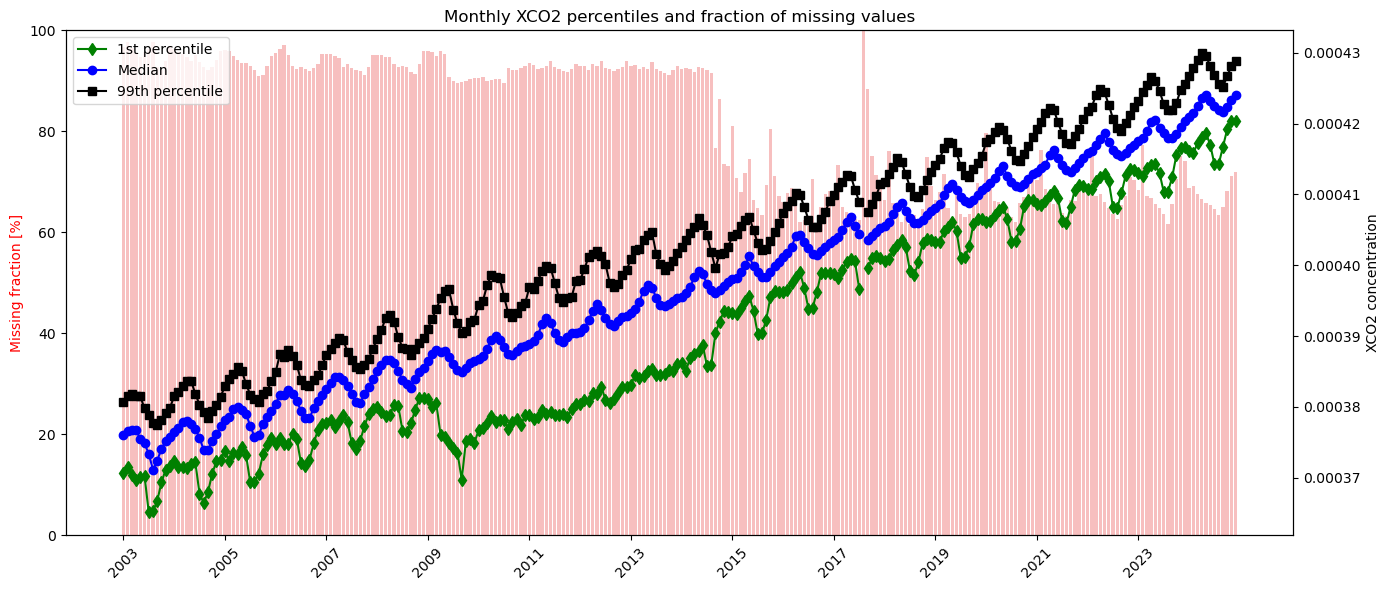

In [74]:
monthly_data = []

var_name = parameter_list[0]

for i in range(len(ds.time)):
    month_values = ds[var_name].isel(time=i).values.flatten()
    # keep only valid numbers
    month_values = month_values[~np.isnan(month_values)]
    monthly_data.append(month_values)

months = pd.to_datetime(ds.time.values).strftime("%Y-%m")
x_pos = np.arange(len(months))

# compute percentiles for all months in timeseries

# Percentiles to compute
pct = [1, 50, 99]

# Store results
percentiles = {p: [] for p in pct}

# Flatten each month and compute percentiles
for i in range(len(ds.time)):
    month_values = ds[var_name].isel(time=i).values.flatten()
    month_values = month_values[~np.isnan(month_values)]  # ignore NaNs
    if len(month_values) == 0:
        # if month is fully missing, use NaN
        for p in pct:
            percentiles[p].append(np.nan)
    else:
        for p in pct:
            percentiles[p].append(np.percentile(month_values, p))

# Convert to DataFrame for convenience
df_pct = pd.DataFrame(percentiles, index=pd.to_datetime(ds.time.values))



# x positions (one per month)
x_pos = np.arange(len(df_pct))

fig, ax1 = plt.subplots(figsize=(14,6))

# -----------------------------
# Bar chart: missing fraction
# -----------------------------
total_cells = ds.sizes["lat"] * ds.sizes["lon"]
missing_count = ds[var_name].isnull().sum(dim=("lat", "lon"))
missing_fraction = missing_count / total_cells * 100

ax1.bar(x_pos, missing_fraction, color="lightcoral", alpha=0.5, label="Missing fraction")
ax1.set_ylabel("Missing fraction [%]", color="red")
ax1.set_ylim(0, 100)
ax1.set_xticks(x_pos)
# Reduce X-axis labels: every other year
months = pd.to_datetime(ds.time.values)
xticks = months[months.month==1][::2]  # pick Jan every other year
xtick_pos = [x_pos[i] for i in range(len(months)) if months[i] in xticks]
ax1.set_xticks(xtick_pos)
ax1.set_xticklabels([d.year for d in xticks], rotation=45)

# -----------------------------
# Percentiles
# -----------------------------
ax2 = ax1.twinx()
colors = ["blue", "green", "black", "orange", "red"]

ax2.plot(x_pos, df_pct[1], marker="d", linestyle="-", color='green', label=f"{1}st percentile")
ax2.plot(x_pos, df_pct[50], marker="o", linestyle="-", color='blue', label=f"Median")
ax2.plot(x_pos, df_pct[99], marker="s", linestyle="-", color='black', label=f"{99}th percentile")

ax2.set_ylabel(f"{GHG_name} concentration")
ax2.set_title("Monthly " + GHG_name + " percentiles and fraction of missing values")
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()